In [ ]:
#Leo Murch
#AST4762
#HW7
#10/12/26

In [ ]:
#Problems 1 - 2 don't require any coding.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#need curve fit for 3.b:
from scipy.optimize import curve_fit

•Problem 3•


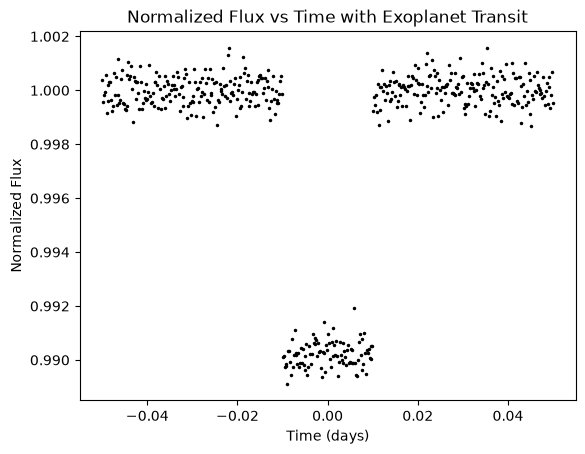

In [23]:
print('•Problem 3•')


#a)

#gonna see if loadtxt works for the data:
#okay there's a title, so i'll specify to skip the first row
transit_curve = np.loadtxt('hw7_synthetic_transit_lightcurve.csv', delimiter=',', skiprows=1)
#specify the delimeter as comma as well

#i can see that in the file it's time vs normalized flux, but I want to try and get that from the file
#and not hardcode it
with open('hw7_synthetic_transit_lightcurve.csv') as f:
    title = next(f).strip().split(',') #title is now an array of two values for x and y title.
f.close()

#print(transit_curve) seems like it worked!

#now for plotting:
t =         transit_curve[:,0]
norm_flux = transit_curve[:,1]

plt.plot(t, norm_flux, 'k.', ms = 3) #shape is 500x2, need [:,n]
plt.xlabel(title[0])
plt.ylabel(title[1]) #awesome no hard coding needed
plt.title('Normalized Flux vs Time with Exoplanet Transit')
plt.show()
#it is kinda interesting that the days are centered around 0 and go to ± on each side.


/var/folders/2x/1z9cgvhx1k1cpt3r4wtwy6ph0000gn/T/ipykernel_14704/3825285740.py:15: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, popv = curve_fit(rect_window, t, norm_flux, [0, 0.02, 0.03]) #some guesses for the values of rect_window by eyeballing


Text(0.5, 1.0, 'Normalized Flux vs Time with Exoplanet Transit')

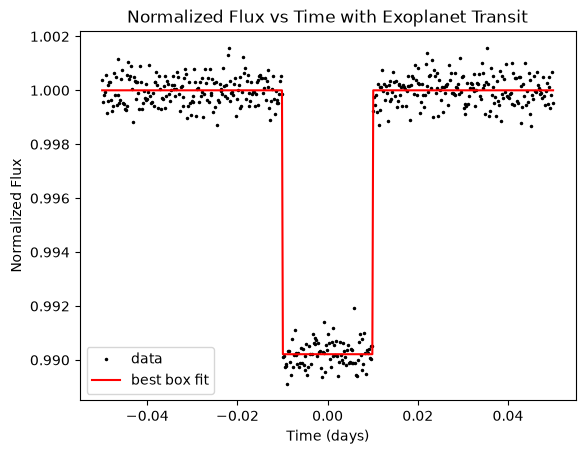

In [42]:
#b)
#define function:
def rect_window(arrx, window_center, width, height):
    """make this once you know when it does""" 

    #±(1/2) of the width scaled from the center to get the good values for the array
    inside =  np.abs(arrx-window_center) <= (0.5*width)
    #use ones like to make another array for the height over these values
    y = np.ones_like(arrx)
    y[inside] = 1. - height #shift the height down from the normal flux over where the width is
    return y

#now use curvefit with this function
#curvefit returns popt which is the best fit for the given parameters (center, width, height)
popt, popv = curve_fit(rect_window, t, norm_flux, [0, 0.02, 0.03]) #some guesses for the values of rect_window by eyeballing
model = rect_window(t, *popt) #*popt passes all the values in order, so i dont have to assign things

#now we can plot this to see how well it fit it:
#code from before with new plotting:

plt.plot(t, norm_flux, 'k.', ms = 3, label = 'data') 
plt.plot(t, model, 'r-', label = 'best box fit')
plt.plot()
plt.xlabel(title[0])
plt.ylabel(title[1]) 
plt.legend()
plt.title('Normalized Flux vs Time with Exoplanet Transit')
#LOOK AT THAT IT WORKED!



In [46]:
#as stated in log, part iii calculation for the R_p
R_star = 1.14
del_FoF = popt[2]
R_p = R_star * np.sqrt(del_FoF)
print(f'Radius of the planet with given values and current best fit is {R_p:.3f}*R_star')

Radius of the planet with given values and current best fit is 0.113*R_star


In [50]:
#c)
#error propagation between everyhting, where we have uncertainty within a power (1/2), multipy in propagation
#errors add up in quadrature
sig_R_star = 0.01
sig_depth = 0.002
sig_result = np.sqrt((sig_R_star / R_star)**2 +  (0.5*sig_depth / del_FoF)**2)
#now multiply by the R_p to isolate the error
planetary_unc = sig_result * R_p
print(f"Result error in Planetary Radius is {planetary_unc:.3f} R_star")

Result error in Planetary Radius is 0.012 R_star
